## Analyze only the users, not the admins.
Analyze only the dates when there were both views and checker commits.
The font size should be 8.
The size of the figure should be (15, 8).
At the end of your Jupyter Notebook, create a Markdown cell and insert the following question: "How many times was the number of views larger than 150?" Insert: "The answer is ____." Replace the underline with the actual number.

<Axes: title={'center': 'Views and commits per day'}, xlabel='date'>

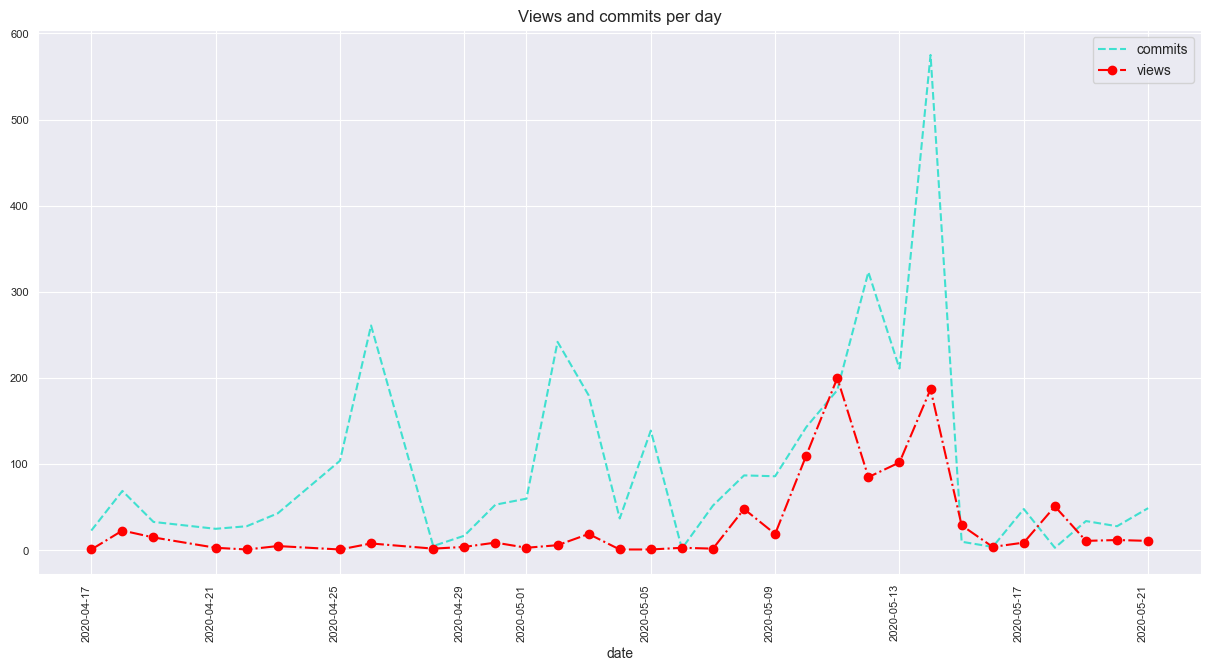

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')

query_dates = """
SELECT
    t1.date,
    t1.commits,
    t2.pageviews AS views
FROM (
    SELECT DATE(timestamp) AS date, COUNT(*) AS commits
    FROM checker
    WHERE uid LIKE 'user_%'
    GROUP BY date
) t1
JOIN (
    SELECT DATE(datetime) AS date, COUNT(*) AS pageviews
    FROM pageviews
    WHERE uid LIKE 'user_%'
    GROUP BY date
) t2 ON t1.date = t2.date
"""
data = pd.read_sql_query(query_dates, conn)
data['date'] = pd.to_datetime(data['date'])
data.plot(title = "Views and commits per day",x='date', y=['commits', 'views'], kind='line', fontsize=8, figsize=(15, 8), style=['--','o-.'], color=['turquoise','r'], rot=90)



Сколько раз количество просмотров превышало 150?

Ответ: 2